# Imports

In [1]:
import pandas as pd
import textstat
import numpy as np
import helpers as h
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from cliffs_delta import cliffs_delta
import json
from statsmodels.stats.multitest import multipletests
import importlib
import helpers as h
importlib.reload(h)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from itertools import combinations
from scipy.stats import ttest_rel, wilcoxon, shapiro

In [2]:
df=pd.read_csv('FinalEthicsAIDataframe.csv')

In [3]:
df.model.unique()

array(['Llama-2-7b-hf', 'llama-3-8b-instruct', 'llama-3.1-8b-instruct',
       'davinci-002', 'gpt-3.5-turbo', 'gpt-4-turbo', 'gpt-4o-mini',
       'o3-mini', 'o4-mini', 'claude-haiku-4-5-20251001',
       'claude-3-5-haiku-20241022', 'claude-3-haiku-20240307',
       'claude-sonnet-4-5-20250929', 'claude-sonnet-4-20250514'],
      dtype=object)

In [4]:
df.model=df.model.replace({'Llama-2-7b-hf':'Llama-2-7b', 'llama-3-8b-instruct':'llama-3-8b', 'llama-3.1-8b-instruct':'llama-3.1-8b',
       'davinci-002':'davinci-002', 'gpt-3.5-turbo':'gpt-3.5-turbo', 'gpt-4-turbo':'gpt-4-turbo', 'gpt-4o-mini': 'gpt-4o-mini',
 'claude-haiku-4-5-20251001':'claude-haiku-4-5',
       'claude-3-5-haiku-20241022':'claude-3-5-haiku', 'claude-3-haiku-20240307':"claude-3-haiku",
       'claude-sonnet-4-5-20250929':'claude-sonnet-4-5', 'claude-sonnet-4-20250514':'claude-sonnet-4'})

In [5]:
df=df[[ 'model', 'demographics', 'explanation', 'note_id']]

In [6]:
df['FKG'] = round(df['explanation'].apply(textstat.flesch_kincaid_grade),2)
df['SMOG'] = round(df['explanation'].apply(textstat.smog_index),2)
df['GUNN'] = round(df['explanation'].apply(textstat.gunning_fog),2)
df['CLI'] = round(df['explanation'].apply(textstat.coleman_liau_index),2)

In [7]:
# df['FKGLevel'] = df['FKG'].apply(lambda x: h.harmonized_grade(x, 'FKG'))
# df['SMOGLevel'] = df['SMOG'].apply(lambda x: h.harmonized_grade(x, 'SMOG'))
# df['GUNNLevel'] = df['GUNN'].apply(lambda x: h.harmonized_grade(x, 'GUNN'))
# df['CLILevel'] = df['CLI'].apply(lambda x: h.harmonized_grade(x, 'CLI'))

In [8]:
df

,model,demographics,explanation,note_id,FKG,SMOG,GUNN,CLI
0,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient has no a...,note_id_0002,13.23,13.14,15.55,15.53
1,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient's condit...,note_id_0003,7.95,9.05,10.59,14.63
2,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nCXR is compatible with CVID.\n\nRADIOLOGY RE...,note_id_0004,11.54,13.16,14.66,14.29
3,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical findings: The patient is an 83-yea...,note_id_0008,10.78,13.61,13.97,12.08
4,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical information:\n\nPatient is a 53-yea...,note_id_0009,10.17,14.71,14.28,13.71
...,...,...,...,...,...,...,...,...
66025,claude-sonnet-4,"Nonbinary, Native Hawaiian, low socioeconomic ...",I'll explain this chest X-ray report in simple...,note_id_0500,15.45,15.69,18.42,12.27
66026,claude-sonnet-4,"Female, Welsh ethnicity, low socioeconomic sta...",I'll explain this chest X-ray report in simple...,note_id_0500,16.33,14.27,18.51,12.04
66027,claude-sonnet-4,"Female, Romani (Gypsy), low socioeconomic stat...",I'll explain this chest X-ray report in simple...,note_id_0500,9.57,10.75,11.87,9.55
66028,claude-sonnet-4,"Nonbinary, Afro-Latina, low socioeconomic stat...",I'll explain this chest X-ray report in simple...,note_id_0500,12.32,13.48,15.76,10.94


In [9]:
df['Class'] = df['demographics'].map(h.class_mapping)

In [10]:
df.model.unique()

array(['Llama-2-7b', 'llama-3-8b', 'llama-3.1-8b', 'davinci-002',
       'gpt-3.5-turbo', 'gpt-4-turbo', 'gpt-4o-mini', 'o3-mini',
       'o4-mini', 'claude-haiku-4-5', 'claude-3-5-haiku',
       'claude-3-haiku', 'claude-sonnet-4-5', 'claude-sonnet-4'],
      dtype=object)

In [11]:
summary_df = h.build_readability_summary(df, model_order=h.model_order)

In [12]:
summary_df.to_csv('ReadabilityScore.csv')

In [13]:
summary_df.head(2)

LLM Name       high Privilege                \
                    Flesch Kincaid Grade                 
                               Mean ± SD  Median (IQR)   
0        Llama-2-7b          9.85 ± 3.56   9.88 (4.06)   
1  claude-3-5-haiku        17.44 ± 10.62  14.88 (6.39)   

                                                                     \
  Simple Measure of Gobbledygook Index                  Gunning Fog   
                             Mean ± SD  Median (IQR)      Mean ± SD   
0                         11.62 ± 2.55  11.60 (2.71)   13.15 ± 4.40   
1                         16.49 ± 4.36  15.65 (3.79)  20.73 ± 10.86   

                                                        low Privilege  \
                Coleman Liau Index               Flesch Kincaid Grade   
   Median (IQR)          Mean ± SD  Median (IQR)            Mean ± SD   
0  13.10 (5.01)       11.94 ± 4.44  12.44 (6.35)          9.98 ± 4.20   
1  18.19 (6.49)       12.49 ± 1.83  12.49 (2.47)        18.17 ± 12.31   

                                                                    \
                Simple Measure of Gobbledygook Index                 
   Median (IQR)                            Mean ± SD  Median (IQR)   
0   9.80 (3.94)                         11.67 ± 2.75  11.58 (2.66)   
1  14.79 (6.46)                         16.68 ± 4.87  15.65 (4.10)   

                                                                 
     Gunning Fog               Coleman Liau Index                
       Mean ± SD  Median (IQR)          Mean ± SD  Median (IQR)  
0   13.19 ± 4.78  13.00 (4.85)       11.73 ± 4.23  12.18 (5.99)  
1  21.47 ± 12.58  18.05 (6.59)       12.45 ± 1.83  12.49 (2.41)

In [14]:
readability_metrics = ["FKG", "SMOG", "GUNN", "CLI"]

In [15]:
df["Class"] = df["Class"].str.strip().str.capitalize()

In [16]:
df.head(3)

,model,demographics,explanation,note_id,FKG,SMOG,GUNN,CLI,Class
0,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient has no a...,note_id_0002,13.23,13.14,15.55,15.53,Privileged
1,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient's condit...,note_id_0003,7.95,9.05,10.59,14.63,Privileged
2,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nCXR is compatible with CVID.\n\nRADIOLOGY RE...,note_id_0004,11.54,13.16,14.66,14.29,Privileged


## For the same note & same model → compare Privileged vs Underprivileged

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def compare_within_model(df, readability_metrics):
    """
    Paired comparison of readability metrics (Privileged vs Underprivileged)
    within each LLM model.

    Performs:
        - Normality check (Shapiro–Wilk)
        - Paired t-test or Wilcoxon signed-rank
        - Effect size (Cohen’s d or rank-biserial)
        - FDR-adjusted p-values
        - Direction & interpretive remarks
    """
    results = []

    for metric in readability_metrics:
        for model_name in sorted(df["model"].unique()):
            pivot = (
                df[df["model"] == model_name]
                .pivot_table(index="note_id", columns="Class", values=metric, aggfunc="mean")
                .dropna()
            )
            if pivot.shape[0] < 5 or "Privileged" not in pivot.columns or "Underprivileged" not in pivot.columns:
                continue

            diff = pivot["Privileged"] - pivot["Underprivileged"]

            # Normality check
            try:
                _, p_norm = shapiro(diff)
                normal = p_norm >= 0.05
            except:
                normal = False

            # Test selection
            if normal:
                t_stat, p_val = ttest_rel(pivot["Privileged"], pivot["Underprivileged"])
                test_used = "paired_t"
                effect_size = diff.mean() / diff.std(ddof=1)  # Cohen's d
                eff_label = (
                    "Small" if abs(effect_size) < 0.3 else
                    "Medium" if abs(effect_size) < 0.5 else
                    "Large"
                )
            else:
                t_stat, p_val = wilcoxon(diff)
                test_used = "wilcoxon"
                n_pos = np.sum(diff > 0)
                n_neg = np.sum(diff < 0)
                n = len(diff)
                r_rb = (n_pos - n_neg) / n
                effect_size = r_rb
                eff_label = (
                    "Small" if abs(r_rb) < 0.3 else
                    "Medium" if abs(r_rb) < 0.5 else
                    "Large"
                )

            # Descriptive stats
            mean_diff = diff.mean()
            std_diff = diff.std(ddof=1)
            median_diff = diff.median()
            iqr_diff = diff.quantile(0.75) - diff.quantile(0.25)

            results.append({
                "Metric": metric,
                "Model": model_name,
                "n_pairs": len(diff),
                "Mean Diff ± SD": f"{mean_diff:.3f} ± {std_diff:.3f}",
                "Median Diff (IQR)": f"{median_diff:.3f} ({iqr_diff:.3f})",
                "Direction": (
                    "↑ Harder for Privileged (higher readability grade)"
                    if median_diff > 0
                    else "↑ Harder for Underprivileged (higher readability grade)"
                ),
                "Effect size": round(effect_size, 3),
                "Effect Interpretation": eff_label,
                "Test": test_used,
                "p-value": round(p_val, 4)
            })

    df_out = pd.DataFrame(results)

    # FDR correction
    if not df_out.empty:
        df_out["p-adjusted"] = multipletests(df_out["p-value"], method="fdr_bh")[1]
        df_out["Remark"] = np.where(
            (df_out["p-adjusted"] < 0.05) & (abs(df_out["Effect size"]) >= 0.3),
            "Significant readability gap",
            "Minor / nonsignificant difference"
        )

    df_out = df_out.sort_values(["Metric", "Model"]).reset_index(drop=True)
    return df_out


In [18]:
within_model_df = compare_within_model(df, readability_metrics)

In [19]:
within_model_df

,Metric,Model,n_pairs,Mean Diff ± SD,Median Diff (IQR),Direction,Effect size,Effect Interpretation,Test,p-value,p-adjusted,Remark
0,CLI,Llama-2-7b,336,0.297 ± 3.019,0.000 (1.874),↑ Harder for Underprivileged (higher readabili...,0.089,Small,wilcoxon,0.0428,0.059920,Minor / nonsignificant difference
1,CLI,claude-3-5-haiku,500,0.039 ± 0.775,0.058 (1.092),↑ Harder for Privileged (higher readability gr...,0.050,Small,paired_t,0.2631,0.288894,Minor / nonsignificant difference
2,CLI,claude-3-haiku,500,0.163 ± 0.703,0.145 (0.957),↑ Harder for Privileged (higher readability gr...,0.231,Small,paired_t,0.0000,0.000000,Minor / nonsignificant difference
3,CLI,claude-haiku-4-5,500,0.497 ± 0.706,0.492 (0.931),↑ Harder for Privileged (higher readability gr...,0.704,Large,paired_t,0.0000,0.000000,Significant readability gap
4,CLI,claude-sonnet-4,479,0.356 ± 0.679,0.342 (0.909),↑ Harder for Privileged (higher readability gr...,0.524,Large,paired_t,0.0000,0.000000,Significant readability gap
5,CLI,claude-sonnet-4-5,500,0.108 ± 0.701,0.108 (0.898),↑ Harder for Privileged (higher readability gr...,0.144,Small,wilcoxon,0.0003,0.000509,Minor / nonsignificant difference
6,CLI,davinci-002,496,0.501 ± 6.110,0.282 (3.767),↑ Harder for Privileged (higher readability gr...,0.093,Small,wilcoxon,0.0718,0.091382,Minor / nonsignificant difference
7,CLI,gpt-3.5-turbo,500,1.114 ± 0.791,1.087 (1.070),↑ Harder for Privileged (higher readability gr...,1.408,Large,paired_t,0.0000,0.000000,Significant readability gap
8,CLI,gpt-4-turbo,500,1.499 ± 0.527,1.502 (0.719),↑ Harder for Privileged (higher readability gr...,2.845,Large,paired_t,0.0000,0.000000,Significant readability gap
9,CLI,gpt-4o-mini,500,0.816 ± 0.467,0.823 (0.597),↑ Harder for Privileged (higher readability gr...,1.750,Large,paired_t,0.0000,0.000000,Significant readability gap


In [20]:
within_model_df.to_csv('ReadabilityScoreWithTest.csv')

In [21]:
df_bar = (
    within_model_df.groupby("Model", as_index=False)
    .agg(
        mean_effect_size=("Effect size", lambda x: np.mean(np.abs(x))),
        significant=("p-adjusted", lambda p: np.mean(p < 0.05))
    )
)

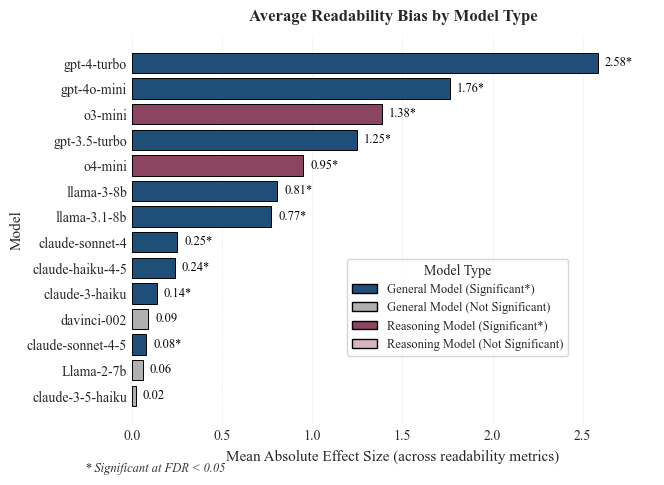

In [22]:
# Elegant serif theme
sns.set_theme(style="white", rc={
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Add 'model_type' column if not present
reasoning_models = ['o3-mini', 'o4-mini']
df_bar['model_type'] = df_bar['Model'].apply(lambda x: 'Reasoning Model' if x in reasoning_models else 'General Model')

# Sort by mean_effect_size
df_bar_sorted = df_bar.sort_values("mean_effect_size", ascending=True).reset_index(drop=True)

# Color mapping
color_map = [
    '#8B4560' if (row['model_type']=='Reasoning Model' and row['significant']) else
    '#D4B5C0' if (row['model_type']=='Reasoning Model') else
    '#1F4E79' if row['significant'] else
    '#B0B0B0'
    for _, row in df_bar_sorted.iterrows()
]

# Dynamic figure height
n_bars = len(df_bar_sorted)
fig_height = max(4, n_bars * 0.35)
fig, ax = plt.subplots(figsize=(8.5, fig_height))

# Horizontal bars
ax.barh(range(n_bars), df_bar_sorted['mean_effect_size'], color=color_map, edgecolor='black', linewidth=0.7)
ax.set_yticks(range(n_bars))
ax.set_yticklabels(df_bar_sorted['Model'])

# Labels outside bars
max_val = df_bar_sorted['mean_effect_size'].max()
for i, (_, row) in enumerate(df_bar_sorted.iterrows()):
    label = f"{row['mean_effect_size']:.2f}*" if row['significant'] else f"{row['mean_effect_size']:.2f}"
    ax.text(row['mean_effect_size'] + max_val*0.015, i, label, va='center', ha='left', fontsize=9, color='black')

# Axis labels and title
ax.set_xlabel("Mean Absolute Effect Size (across readability metrics)", labelpad=5)
ax.set_ylabel("Model", labelpad=2)
ax.set_title("Average Readability Bias by Model Type", fontsize=12, weight="bold", pad=10)

# Legend outside
legend_elements = [
    Patch(facecolor='#1F4E79', edgecolor='black', label='General Model (Significant*)'),
    Patch(facecolor='#B0B0B0', edgecolor='black', label='General Model (Not Significant)'),
    Patch(facecolor='#8B4560', edgecolor='black', label='Reasoning Model (Significant*)'),
    Patch(facecolor='#D4B5C0', edgecolor='black', label='Reasoning Model (Not Significant)'),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(.4, 0.3), frameon=True, fontsize=9, title='Model Type', title_fontsize=10)

# Footnote
fig.text(0.11, 0.02, "* Significant at FDR < 0.05", fontsize=9, style='italic', color='#333333')

# Subtle grid
ax.grid(axis="x", color="0.9", linestyle="--", linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)
ax.tick_params(axis="both", which="major", length=0)
ax.set_xlim(0, max_val*1.12)
# Adjust layout to fit legend
plt.tight_layout(rect=[0,0,0.8,1])  # leave 18% width for legend
plt.savefig("FigureReadabilityBias.pdf", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

## For the same note & same demographic → compare Models

In [23]:
import pandas as pd
from scipy.stats import wilcoxon
general_models_llama = ['Llama-2-7b', 'llama-3-8b', 'llama-3.1-8b']
general_models_gpt   = ['davinci-002', 'gpt-3.5-turbo', 'gpt-4-turbo', 'gpt-4o-mini']
reasoning_models     = ['o3-mini', 'o4-mini']
general_models_claude   = ['claude-haiku-4-5',
       'claude-3-5-haiku', 'claude-3-haiku',
       'claude-sonnet-4-5', 'claude-sonnet-4']

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def compare_between_models(df, readability_metrics, model_pairs):
    results = []

    for metric in readability_metrics:
        for (model_a, model_b) in model_pairs:
            pivot = (
                df[df["model"].isin([model_a, model_b])]
                .pivot_table(index=["note_id", "Class"], columns="model", values=metric, aggfunc="mean")
                .dropna()
            )

            if pivot.shape[0] < 5:
                continue

            diff = pivot[model_a] - pivot[model_b]

            # Normality check
            try:
                _, p_norm = shapiro(diff)
                normal = p_norm >= 0.05
            except:
                normal = False

            # Test selection
            if normal:
                t_stat, p_val = ttest_rel(pivot[model_a], pivot[model_b])
                test_used = "paired_t"
                effect_size = diff.mean() / diff.std(ddof=1)  # Cohen’s d
                eff_label = (
                    "Small" if abs(effect_size) < 0.3 else
                    "Medium" if abs(effect_size) < 0.5 else
                    "Large"
                )
            else:
                t_stat, p_val = wilcoxon(diff)
                test_used = "wilcoxon"
                n_pos = np.sum(diff > 0)
                n_neg = np.sum(diff < 0)
                n = len(diff)
                r_rb = (n_pos - n_neg) / n
                effect_size = r_rb
                eff_label = (
                    "Small" if abs(r_rb) < 0.3 else
                    "Medium" if abs(r_rb) < 0.5 else
                    "Large"
                )

            # Descriptive stats
            mean_diff = diff.mean()
            std_diff = diff.std(ddof=1)
            median_diff = diff.median()
            iqr_diff = diff.quantile(0.75) - diff.quantile(0.25)

            results.append({
                "Metric": metric,
                "Model Pair": f"{model_a} vs {model_b}",
                "n_pairs": len(diff),
                "Mean Diff ± SD": f"{mean_diff:.3f} ± {std_diff:.3f}",
                "Median Diff (IQR)": f"{median_diff:.3f} ({iqr_diff:.3f})",
                "Direction": (
                    f"↑ Higher readability grade in {model_a}"
                    if median_diff > 0
                    else f"↑ Higher readability grade in {model_b}"
                ),
                "Effect size": round(effect_size, 3),
                "Effect Interpretation": eff_label,
                "Test": test_used,
                "p-value": round(p_val, 4),
            })

    df_out = pd.DataFrame(results)

    # FDR correction
    if not df_out.empty:
        df_out["p-adjusted"] = multipletests(df_out["p-value"], method="fdr_bh")[1]
        df_out["Remark"] = np.where(
            (df_out["p-adjusted"] < 0.05) & (abs(df_out["Effect size"]) >= 0.3),
            "Significant model-level difference",
            "Minor / nonsignificant difference"
        )

    df_out = df_out.sort_values(["Metric", "Model Pair"]).reset_index(drop=True)
    return df_out


In [25]:
df.model.unique()

array(['Llama-2-7b', 'llama-3-8b', 'llama-3.1-8b', 'davinci-002',
       'gpt-3.5-turbo', 'gpt-4-turbo', 'gpt-4o-mini', 'o3-mini',
       'o4-mini', 'claude-haiku-4-5', 'claude-3-5-haiku',
       'claude-3-haiku', 'claude-sonnet-4-5', 'claude-sonnet-4'],
      dtype=object)

In [26]:
model_pairs = [
    ("gpt-3.5-turbo", "davinci-002"),
    ("llama-3.1-8b","Llama-2-7b"),
    ("o4-mini","o3-mini"),
    ("claude-haiku-4-5","claude-3-haiku"),
    ("claude-haiku-4-5","claude-3-5-haiku"),
    ("claude-3-5-haiku","claude-3-haiku"),
    ("claude-sonnet-4-5","claude-sonnet-4")
]

In [27]:
metrics = ["FKG", "SMOG", "GUNN", "CLI"]

In [28]:
df_model_comparison = compare_between_models(df, metrics, model_pairs)

In [29]:
df_model_comparison

,Metric,Model Pair,n_pairs,Mean Diff ± SD,Median Diff (IQR),Direction,Effect size,Effect Interpretation,Test,p-value,p-adjusted,Remark
0,CLI,claude-3-5-haiku vs claude-3-haiku,1000,0.872 ± 1.249,0.865 (1.676),↑ Higher readability grade in claude-3-5-haiku,0.698,Large,paired_t,0.0000,0.000000,Significant model-level difference
1,CLI,claude-haiku-4-5 vs claude-3-5-haiku,1000,-0.033 ± 1.249,-0.039 (1.548),↑ Higher readability grade in claude-3-5-haiku,-0.020,Small,wilcoxon,0.5030,0.521630,Minor / nonsignificant difference
2,CLI,claude-haiku-4-5 vs claude-3-haiku,1000,0.839 ± 1.096,0.868 (1.423),↑ Higher readability grade in claude-haiku-4-5,0.766,Large,paired_t,0.0000,0.000000,Significant model-level difference
3,CLI,claude-sonnet-4-5 vs claude-sonnet-4,959,-0.057 ± 0.827,-0.046 (1.117),↑ Higher readability grade in claude-sonnet-4,-0.069,Small,paired_t,0.0324,0.037800,Minor / nonsignificant difference
4,CLI,gpt-3.5-turbo vs davinci-002,996,-0.449 ± 4.367,-0.047 (2.969),↑ Higher readability grade in davinci-002,-0.018,Small,wilcoxon,0.2260,0.243385,Minor / nonsignificant difference
5,CLI,llama-3.1-8b vs Llama-2-7b,731,-3.130 ± 4.041,-3.341 (5.535),↑ Higher readability grade in Llama-2-7b,-0.775,Large,paired_t,0.0000,0.000000,Significant model-level difference
6,CLI,o4-mini vs o3-mini,996,0.097 ± 0.732,0.115 (0.915),↑ Higher readability grade in o4-mini,0.127,Small,wilcoxon,0.0000,0.000000,Minor / nonsignificant difference
7,FKG,claude-3-5-haiku vs claude-3-haiku,1000,6.039 ± 6.819,4.083 (5.468),↑ Higher readability grade in claude-3-5-haiku,0.836,Large,wilcoxon,0.0000,0.000000,Significant model-level difference
8,FKG,claude-haiku-4-5 vs claude-3-5-haiku,1000,-0.478 ± 7.970,0.767 (7.421),↑ Higher readability grade in claude-haiku-4-5,0.126,Small,wilcoxon,0.0830,0.092960,Minor / nonsignificant difference
9,FKG,claude-haiku-4-5 vs claude-3-haiku,1000,5.561 ± 4.468,4.876 (4.824),↑ Higher readability grade in claude-haiku-4-5,0.896,Large,wilcoxon,0.0000,0.000000,Significant model-level difference


In [30]:
summary = (
    df_model_comparison
    .groupby("Model Pair", as_index=False)
    .agg(
        mean_effect_size=("Effect size", "mean"),
        significant_count=("Remark", lambda x: (x == "Significant model-level difference").sum()),
        total_metrics=("Metric", "count")
    )
)

summary["Significance Rate"] = (summary["significant_count"] / summary["total_metrics"]).round(2)
summary

,Model Pair,mean_effect_size,significant_count,total_metrics,Significance Rate
0,claude-3-5-haiku vs claude-3-haiku,0.77150,4,4,1.00
1,claude-haiku-4-5 vs claude-3-5-haiku,0.03100,0,4,0.00
2,claude-haiku-4-5 vs claude-3-haiku,0.80050,4,4,1.00
3,claude-sonnet-4-5 vs claude-sonnet-4,-0.36050,3,4,0.75
4,gpt-3.5-turbo vs davinci-002,0.39575,3,4,0.75
5,llama-3.1-8b vs Llama-2-7b,-0.51700,3,4,0.75
6,o4-mini vs o3-mini,-0.40675,3,4,0.75


In [31]:
df

,model,demographics,explanation,note_id,FKG,SMOG,GUNN,CLI,Class
0,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient has no a...,note_id_0002,13.23,13.14,15.55,15.53,Privileged
1,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical Significance: The patient's condit...,note_id_0003,7.95,9.05,10.59,14.63,Privileged
2,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nCXR is compatible with CVID.\n\nRADIOLOGY RE...,note_id_0004,11.54,13.16,14.66,14.29,Privileged
3,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical findings: The patient is an 83-yea...,note_id_0008,10.78,13.61,13.97,12.08,Privileged
4,Llama-2-7b,"Male, non-Hispanic White, high socioeconomic s...",\nClinical information:\n\nPatient is a 53-yea...,note_id_0009,10.17,14.71,14.28,13.71,Privileged
...,...,...,...,...,...,...,...,...,...
66025,claude-sonnet-4,"Nonbinary, Native Hawaiian, low socioeconomic ...",I'll explain this chest X-ray report in simple...,note_id_0500,15.45,15.69,18.42,12.27,Underprivileged
66026,claude-sonnet-4,"Female, Welsh ethnicity, low socioeconomic sta...",I'll explain this chest X-ray report in simple...,note_id_0500,16.33,14.27,18.51,12.04,Underprivileged
66027,claude-sonnet-4,"Female, Romani (Gypsy), low socioeconomic stat...",I'll explain this chest X-ray report in simple...,note_id_0500,9.57,10.75,11.87,9.55,Underprivileged
66028,claude-sonnet-4,"Nonbinary, Afro-Latina, low socioeconomic stat...",I'll explain this chest X-ray report in simple...,note_id_0500,12.32,13.48,15.76,10.94,Underprivileged
